In [20]:
#Dataset
from sklearn.datasets import make_regression
import pandas as pd

# Create dataset
X, y = make_regression(
    n_samples=30,
    n_features=1,
    noise=25,
    random_state=42
)

# Convert into DataFrame
data = pd.DataFrame({
    'Feature': X.flatten(),
    'Target': y
})

# Show dataset
print(data.head())

    Feature      Target
0 -1.150994 -116.458614
1 -0.562288  -51.927111
2 -0.138264  -13.504385
3 -0.234137   -6.286701
4  1.523030  104.072536


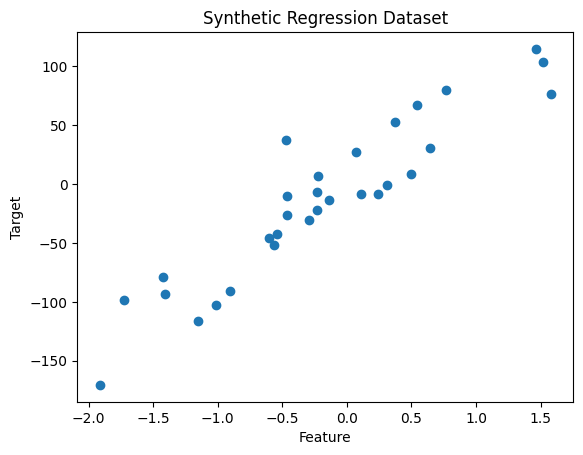

In [21]:
#Visualization
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.xlabel("Feature")
plt.ylabel("Target")

plt.title("Synthetic Regression Dataset")

plt.show()

# ***1.Hold-Out Approach***

In [25]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create synthetic regression dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=76
)

# Hold-Out Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))

# Parameters
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
#Drawback->random_state change->Different split → different training data → different learned patterns → different accuracy.

R2 Score: 0.3407423485761314
Slope: 20.252050029388666
Intercept: -0.4085170035425426


# ***2.Cross Validation***

***i.Leave-One-Out Cross Validation***

In [15]:
from sklearn.datasets import make_regression
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = LinearRegression()

# LOOCV
cv = LeaveOneOut()

# Use NEGATIVE MSE
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_squared_error'
)

# Convert to positive
mse = -scores.mean()

print("LOOCV MSE:", mse)

#Drawback->Very slow computationally , R² cannot be used in LOOCV regression
#because each test fold contains only one sample.

LOOCV MSE: 647.8742385584999


***ii.Leave P-Out***

In [19]:
from sklearn.datasets import make_regression
from sklearn.model_selection import LeavePOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Create dataset
X, y = make_regression(
    n_samples=30,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = LinearRegression()

# Leave-P-Out
cv = LeavePOut(p=2)

# Cross Validation using MSE
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='neg_mean_squared_error'
)

# Convert negative to positive
mse = -scores.mean()

print("Leave-P-Out MSE:", mse)
#Drawback->1. Extremely slow 2. Computationally expensive 3. R2 becomes unstable for small p

Leave-P-Out MSE: 701.3513248929355


***iii.K-Fold*** (All k-fold ha sdrawback that they are computationally expensive)

In [27]:
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=1
)

# Model
model = LinearRegression()

# KFold
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print("K-Fold R2 Scores:", scores)
print("Mean R2 Score:", scores.mean())

#This time R2 doesnt change as random state change

K-Fold R2 Scores: [0.88476469 0.88178275 0.93999591 0.92007739 0.8955476 ]
Mean R2 Score: 0.9044336694467109


***iv.Stratified K-Fold (Classification Only)***

In [28]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

***v.Repeated K-Fold***

In [29]:
from sklearn.datasets import make_regression
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = LinearRegression()

# Repeated KFold
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# Cross Validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print("Repeated K-Fold Mean R2:", scores.mean())

Repeated K-Fold Mean R2: 0.904825544207022


***vi.Nested K-Fold***

In [30]:
from sklearn.datasets import make_regression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = Ridge()

# Hyperparameters
param_grid = {
    'alpha': [0.1, 1, 10, 100]
}

# Inner CV
inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='r2'
)

# Outer CV
outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Nested Cross Validation
scores = cross_val_score(
    grid,
    X,
    y,
    cv=outer_cv,
    scoring='r2'
)

print("Nested K-Fold R2 Scores:", scores)
print("Mean Nested R2:", scores.mean())

Nested K-Fold R2 Scores: [0.91663098 0.94093391 0.89911215 0.91271481 0.82692239]
Mean Nested R2: 0.8992628471270369


# ***3.Boostrapping(Simple random sampling with replacement/SRSWR)***

In [31]:
from sklearn.datasets import make_regression
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = LinearRegression()

scores = []

# Bootstrap iterations
for i in range(100):

    # Sampling WITH replacement
    X_boot, y_boot = resample(
        X,
        y,
        replace=True,
        n_samples=len(X),
        random_state=i
    )

    # Train
    model.fit(X_boot, y_boot)

    # Predict on original data
    y_pred = model.predict(X)

    # R2 Score
    scores.append(r2_score(y, y_pred))

# Average Score
print("Bootstrap Mean R2:", np.mean(scores))

#Drawback-Duplicate samples may cause overfitting.

Bootstrap Mean R2: 0.9101926027607109


# ***4.Permutation Test***

In [32]:
from sklearn.datasets import make_regression
from sklearn.model_selection import permutation_test_score
from sklearn.linear_model import LinearRegression

# Dataset
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=25,
    random_state=42
)

# Model
model = LinearRegression()

# Permutation Test
score, permutation_scores, pvalue = permutation_test_score(
    model,
    X,
    y,
    scoring="r2",
    cv=5,
    n_permutations=100,
    random_state=42
)

print("Original R2 Score:", score)
print("P-Value:", pvalue)

'''
Low p-value (< 0.05)
→ model learned real pattern

High p-value
→ performance may be due to randomness

Drawback-
Very computationally expensive
because model trains many times.
'''

Original R2 Score: 0.9054912241258073
P-Value: 0.009900990099009901


Permutation Test:-
Train on Original Data
        ,
Get Original Score
        ,
Shuffle Target
        ,
Train Again
        ,
Get New Score
        ,
Repeat Many Times